In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.utils import resample
import pandas as pd
import numpy as np
import itertools
from sklearn.inspection import permutation_importance
from statsmodels.stats.multitest import multipletests



In [23]:
atp_matches_2021 = pd.read_csv('atp_matches_2021.csv')
atp_matches_2022 = pd.read_csv('atp_matches_2022.csv')
atp_matches_2023 = pd.read_csv('atp_matches_2023.csv')
atp_matches_2024 = pd.read_csv('atp_matches_2024.csv')

lista_ramek = [atp_matches_2021,atp_matches_2022, atp_matches_2023, atp_matches_2024]


df_atp_wszystkie = pd.concat(lista_ramek, axis=0, ignore_index=True)

stats_columns = [
    'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced',
    'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced','winner_rank','loser_rank'
]

df_clean = df_atp_wszystkie.dropna(subset=stats_columns).copy()

In [24]:
df_atp_wszystkie.isnull().sum()

tourney_id               0
tourney_name             0
surface                 53
draw_size                0
tourney_level            0
tourney_date             0
match_num                0
winner_id                0
winner_seed           6783
winner_entry          9917
winner_name              0
winner_hand              0
winner_ht               47
winner_ioc               0
winner_age               2
loser_id                 0
loser_seed            8788
loser_entry           9010
loser_name               0
loser_hand               0
loser_ht               122
loser_ioc                0
loser_age                3
score                    0
best_of                  0
round                    0
minutes                833
w_ace                  500
w_df                   500
w_svpt                 500
w_1stIn                500
w_1stWon               500
w_2ndWon               500
w_SvGms                500
w_bpSaved              500
w_bpFaced              500
l_ace                  500
l

In [25]:
df_clean['tourney_date'] = pd.to_datetime(df_clean['tourney_date'], format='%Y%m%d')
df_clean = df_clean.sort_values(by=['tourney_date', 'match_num'], ascending=True)
df_clean = df_clean.reset_index(drop=True)

cols_to_impute = ['winner_age', 'loser_age', 'winner_ht', 'loser_ht']
for col in cols_to_impute:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [26]:
def create_player_based_dataset(df):
    np.random.seed(123)

    new_df = pd.DataFrame()

    common_cols = [
        'tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
        'tourney_date', 'match_num', 'score', 'best_of', 'round', 'minutes'
    ]
    for col in common_cols:
        if col in df.columns:
            new_df[col] = df[col]

    swap_mask = np.random.rand(len(df)) > 0.5

    column_pairs = [
        ('winner_id', 'loser_id', 'id'),
        ('winner_seed', 'loser_seed', 'seed'),
        ('winner_entry', 'loser_entry', 'entry'),
        ('winner_name', 'loser_name', 'name'),
        ('winner_hand', 'loser_hand', 'hand'),
        ('winner_ht', 'loser_ht', 'ht'),
        ('winner_ioc', 'loser_ioc', 'ioc'),
        ('winner_age', 'loser_age', 'age'),
        ('winner_rank', 'loser_rank', 'rank'),
        ('winner_rank_points', 'loser_rank_points', 'rank_points'),

        ('w_ace', 'l_ace', 'ace'),
        ('w_df', 'l_df', 'df'),
        ('w_svpt', 'l_svpt', 'svpt'),
        ('w_1stIn', 'l_1stIn', '1stIn'),
        ('w_1stWon', 'l_1stWon', '1stWon'),
        ('w_2ndWon', 'l_2ndWon', '2ndWon'),
        ('w_SvGms', 'l_SvGms', 'SvGms'),
        ('w_bpSaved', 'l_bpSaved', 'bpSaved'),
        ('w_bpFaced', 'l_bpFaced', 'bpFaced')
    ]
    for w_col, l_col, base_name in column_pairs:
        p1_col_name = f'p1_{base_name}'
        p2_col_name = f'p2_{base_name}'
        new_df[p1_col_name] = np.where(swap_mask, df[l_col], df[w_col])
        new_df[p2_col_name] = np.where(swap_mask, df[w_col], df[l_col])
    new_df['target'] = np.where(swap_mask, 0, 1)

    return new_df

In [27]:
df_model_ready = create_player_based_dataset(df_clean)
df_model_ready.isnull().sum()

tourney_id           0
tourney_name         0
surface              0
draw_size            0
tourney_level        0
tourney_date         0
match_num            0
score                0
best_of              0
round                0
minutes            383
p1_id                0
p2_id                0
p1_seed           7233
p2_seed           7301
p1_entry          8869
p2_entry          8920
p1_name              0
p2_name              0
p1_hand              0
p2_hand              0
p1_ht                0
p2_ht                0
p1_ioc               0
p2_ioc               0
p1_age               0
p2_age               0
p1_rank              0
p2_rank              0
p1_rank_points       0
p2_rank_points       0
p1_ace               0
p2_ace               0
p1_df                0
p2_df                0
p1_svpt              0
p2_svpt              0
p1_1stIn             0
p2_1stIn             0
p1_1stWon            0
p2_1stWon            0
p1_2ndWon            0
p2_2ndWon            0
p1_SvGms   

In [28]:
def add_rolling_stats(df, window_size=5):

    df_p1 = df[['tourney_date', 'p1_name',
                'p1_ace', 'p1_df', 'p1_1stIn', 'p1_1stWon', 'p1_2ndWon', 'p1_bpSaved',
                'target']].copy()
    df_p1.columns = ['date', 'player',
                     'ace', 'df', '1stIn', '1stWon', '2ndWon', 'bpSaved',
                     'won']
    df_p1['match_index'] = df.index
    df_p1['is_p1'] = True


    df_p2 = df[['tourney_date', 'p2_name',
                'p2_ace', 'p2_df', 'p2_1stIn', 'p2_1stWon', 'p2_2ndWon', 'p2_bpSaved',
                'target']].copy()
    df_p2['won'] = df['target'].apply(lambda x: 0 if x == 1 else 1)  # 
    df_p2 = df_p2.drop('target', axis=1)
    df_p2.columns = ['date', 'player',
                     'ace', 'df', '1stIn', '1stWon', '2ndWon', 'bpSaved',
                     'won']
    df_p2['match_index'] = df.index
    df_p2['is_p1'] = False



    df_long = pd.concat([df_p1, df_p2], ignore_index=True)
    df_long = df_long.sort_values(['player', 'date'])

    roll_cols = ['ace', 'df', '1stIn', '1stWon', '2ndWon', 'bpSaved', 'won']

    for col in roll_cols:
        df_long[f'avg_{col}_last_{window_size}'] = (
            df_long.groupby('player')[col]
            .transform(lambda x: x.rolling(window_size, min_periods=1).mean().shift(1))
        )

    p1_stats = df_long[df_long['is_p1']].set_index('match_index')[
        [f'avg_{c}_last_{window_size}' for c in roll_cols]
    ]
    p1_stats.columns = [f'p1_{c}' for c in p1_stats.columns]
    p2_stats = df_long[df_long['is_p1'] == False].set_index('match_index')[
        [f'avg_{c}_last_{window_size}' for c in roll_cols]
    ]
    p2_stats.columns = [f'p2_{c}' for c in p2_stats.columns]
    df_final = df.join(p1_stats).join(p2_stats)
    return df_final



df_enriched = add_rolling_stats(df_model_ready, window_size=10)


df_enriched['rank_diff'] = df_enriched['p1_rank'] - df_enriched['p2_rank']
df_enriched['age_diff'] = df_enriched['p1_age'] - df_enriched['p2_age']
df_enriched['height_diff'] = df_enriched['p1_ht'] - df_enriched['p2_ht']
df_enriched['rank_points_diff'] = df_enriched['p1_rank_points'] - df_enriched['p2_rank_points']

rolling_cols = [c for c in df_enriched.columns if 'avg_' in c]
df_ready_for_ai = df_enriched.dropna(subset=rolling_cols)

In [29]:
def process_hands(df):
    df_hands = df.copy()
    mapping = {'R': 0, 'L': 1, 'U': 0}
    df_hands['p1_hand'] = df_hands['p1_hand'].fillna('R')
    df_hands['p2_hand'] = df_hands['p2_hand'].fillna('R')
    df_hands['p1_is_left'] = df_hands['p1_hand'].map(mapping).fillna(0)
    df_hands['p2_is_left'] = df_hands['p2_hand'].map(mapping).fillna(0)
    df_hands['is_diff_hand'] = (df_hands['p1_is_left'] != df_hands['p2_is_left']).astype(int)
    return df_hands

df_ready_for_ai = process_hands(df_ready_for_ai)
df_eda = df_ready_for_ai.copy() 

In [30]:
poziomy_turniejow = df_eda['tourney_level'].value_counts()
print(poziomy_turniejow)

tourney_level
A    5809
M    2378
G    1969
D     302
F      74
O      57
Name: count, dtype: int64


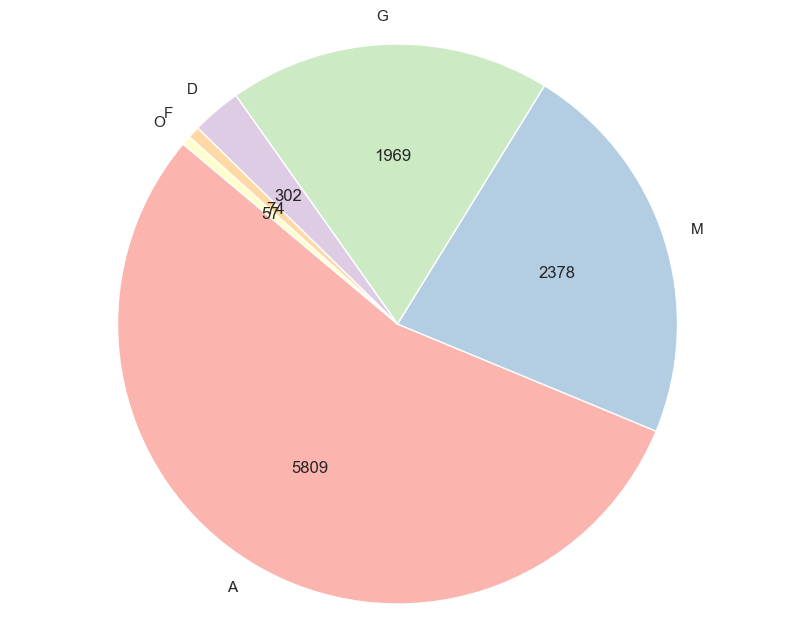

tourney_level
A    0.484076
D    0.509934
F    0.581081
G    0.513966
M    0.510093
O    0.403509
Name: target, dtype: float64


In [31]:
def func(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{absolute}"

plt.figure(figsize=(10, 8))
plt.pie(poziomy_turniejow, 
        labels=poziomy_turniejow.index, 
        autopct=lambda pct: func(pct, poziomy_turniejow),
        startangle=140, 
        colors=plt.cm.Pastel1.colors)

plt.axis('equal')
plt.show()

srednia_target = df_eda.groupby('tourney_level')['target'].mean()
print(srednia_target)

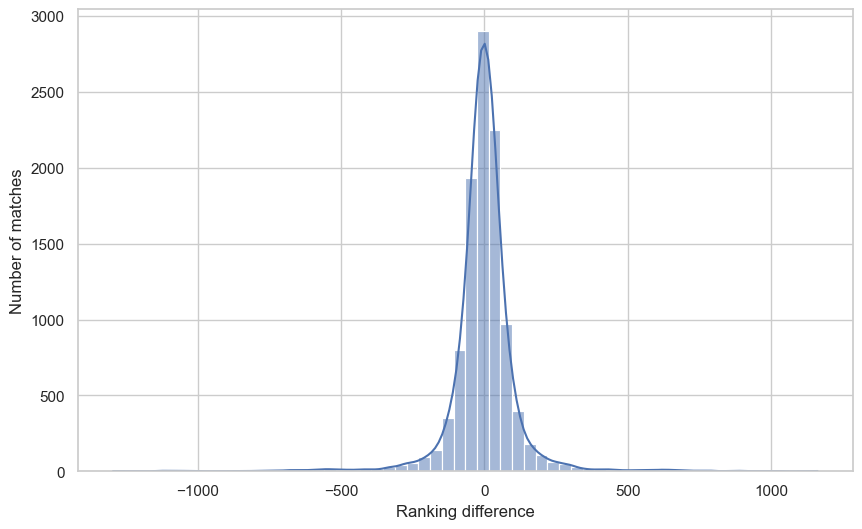

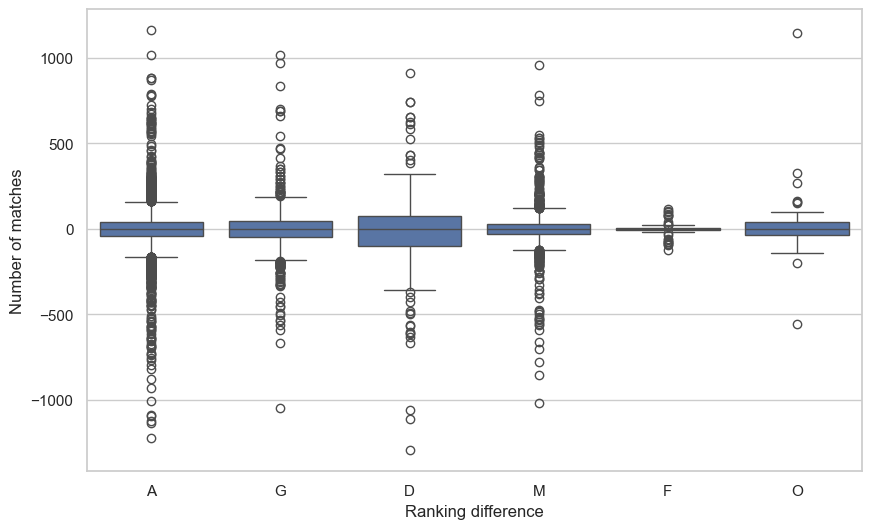

In [43]:
df_eda['rank_diff'] = df_eda['p1_rank'] - df_eda['p2_rank']
df_eda = df_eda.dropna(subset=['rank_diff'])

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6)) 
sns.histplot(data=df_eda, x='rank_diff', bins=60, kde=True)
plt.xlabel('Ranking difference')
plt.ylabel('Number of matches')
plt.show() 

plt.figure(figsize=(10, 6)) 
sns.boxplot(data=df_eda, x='tourney_level', y='rank_diff')
plt.xlabel('Ranking difference')
plt.ylabel('Number of matches')
plt.show()

surface         Clay  Grass   Hard
tourney_level                     
A              0.321  0.124  0.556
D              0.146  0.010  0.844
F              0.000  0.000  1.000
G              0.249  0.251  0.499
M              0.339  0.000  0.661
O              1.000  0.000  0.000
best_of            3      5
tourney_level              
A              0.997  0.003
D              1.000  0.000
F              0.608  0.392
G              0.000  1.000
M              1.000  0.000
O              1.000  0.000


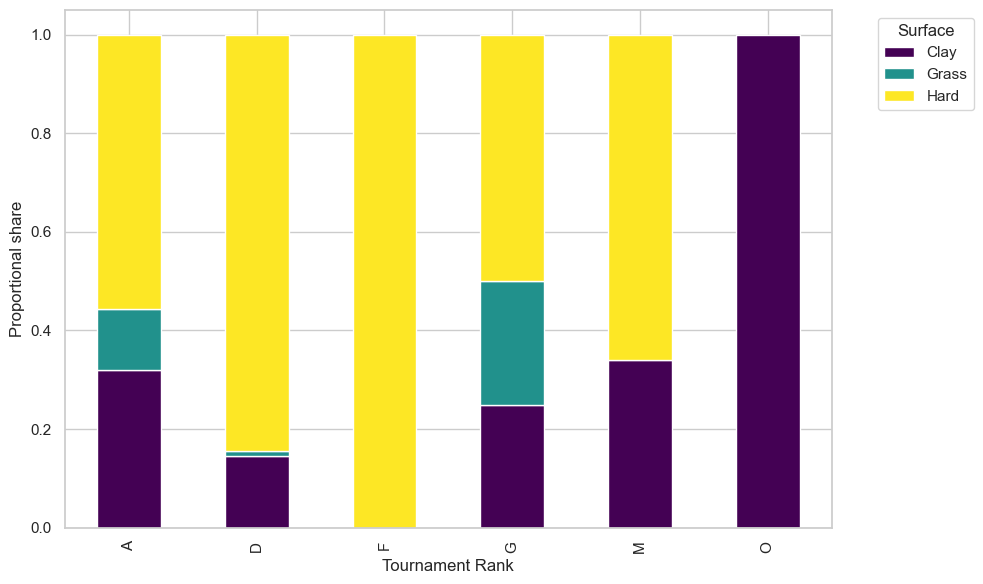

In [33]:
surface_props = pd.crosstab(df_eda['tourney_level'], df_eda['surface'], normalize='index')
print(surface_props.round(3)) 

best_of_props = pd.crosstab(df_eda['tourney_level'], df_eda['best_of'], normalize='index')
print(best_of_props.round(3))


ax1 = surface_props.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
ax1.set_xlabel('Tournament Rank')
ax1.set_ylabel('Proportional share')
ax1.legend(title='Surface', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show() 

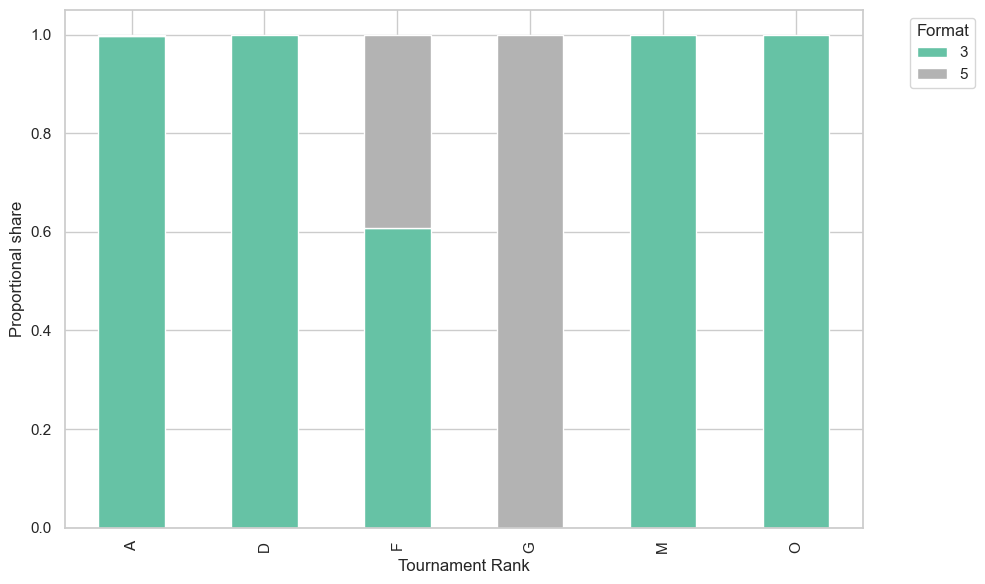

In [34]:
ax2 = best_of_props.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
ax2.set_xlabel('Tournament Rank')
ax2.set_ylabel('Proportional share')
ax2.legend(title='Format', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show() 

In [35]:
df_eda = df_eda.sort_values(by=['tourney_date', 'match_num']).reset_index(drop=True)

df_baseline = df_eda.dropna(subset=['p1_rank', 'p2_rank']).copy()

split_index = int(len(df_baseline) * 0.8)

df_train = df_baseline.iloc[:split_index]
df_test = df_baseline.iloc[split_index:].copy()

df_test['baseline_pred'] = (df_test['p1_rank'] < df_test['p2_rank']).astype(int)

global_accuracy = accuracy_score(df_test['target'], df_test['baseline_pred'])
print(f"\nGlobal Accuracy of the baseline: {global_accuracy:.4f} ({global_accuracy * 100:.2f}%)")

baseline_by_level = df_test.groupby('tourney_level').apply(
    lambda x: accuracy_score(x['target'], x['baseline_pred']),
    include_groups=False
)

print((baseline_by_level * 100).round(2).sort_values(ascending=False))



Global Accuracy of the baseline: 0.6256 (62.56%)
tourney_level
O    73.68
G    71.20
M    63.39
D    61.73
A    58.42
F    55.17
dtype: float64


In [36]:
win=10
features = ['p1_rank','p2_rank',
    'rank_diff', 'rank_points_diff', 'age_diff', 'height_diff',
    'p1_is_left',  'p2_is_left',  'is_diff_hand',
    f'p1_avg_ace_last_{win}', f'p1_avg_df_last_{win}', f'p1_avg_1stIn_last_{win}', 
    f'p1_avg_1stWon_last_{win}', f'p1_avg_2ndWon_last_{win}', f'p1_avg_bpSaved_last_{win}', f'p1_avg_won_last_{win}',
    
    f'p2_avg_ace_last_{win}', f'p2_avg_df_last_{win}', f'p2_avg_1stIn_last_{win}', 
    f'p2_avg_1stWon_last_{win}', f'p2_avg_2ndWon_last_{win}', f'p2_avg_bpSaved_last_{win}', f'p2_avg_won_last_{win}'
]
target = 'target' 



In [37]:
df_model = df_eda.sort_values(by=['tourney_date', 'match_num']).dropna(subset=features + ['target']).copy()
df_model = pd.get_dummies(df_model, columns=['surface'], drop_first=True)
cechy_surface = [col for col in df_model.columns if col.startswith('surface_')]
wszystkie_cechy = cechy_surface + features

wyniki_bootstrap = []
poziomy_turniejow = [level for level in df_model['tourney_level'].unique() if len(df_model[df_model['tourney_level'] == level]) >= 100]
n_bootstraps = 1000 

In [38]:
trained_models = {}

for level in poziomy_turniejow:
    df_level = df_model[df_model['tourney_level'] == level].copy()
    
    X = df_level[wszystkie_cechy]
    y = df_level['target']

    split_index = int(len(df_level) * 0.8)
    X_train, y_train = X.iloc[:split_index], y.iloc[:split_index]
    X_test, y_test = X.iloc[split_index:], y.iloc[split_index:]
    
    tscv = TimeSeriesSplit(n_splits=5)

    preprocessor = ColumnTransformer(
        transformers=[
            ('surface', 'passthrough', cechy_surface),
            ('num', StandardScaler(), features)
        ]
    )
    pipe_lr = Pipeline([
        ('preprocessor', preprocessor),
        ('lr', LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=123))
    ])
    grid_lr = GridSearchCV(pipe_lr, {'lr__C': [0.01, 0.1, 1.0, 10.0]}, cv=tscv, scoring='accuracy')
    grid_lr.fit(X_train, y_train)
    
    rf = RandomForestClassifier(random_state=123)
    param_grid_rf = {'n_estimators': [30,50,70,100], 'max_depth': [5, 10], 'min_samples_leaf': [1, 5]}
    grid_rf = GridSearchCV(rf, param_grid_rf, cv=tscv, scoring='accuracy', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    
    y_pred_lr = grid_lr.predict(X_test)
    y_proba_lr = grid_lr.predict_proba(X_test)[:, 1] 
    
    y_pred_rf = grid_rf.predict(X_test)
    y_proba_rf = grid_rf.predict_proba(X_test)[:, 1]
    
    trained_models[level] = {
        'lr': grid_lr.best_estimator_,
        'rf': grid_rf.best_estimator_,
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred_lr': y_pred_lr,
        'y_proba_lr': y_proba_lr,
        'y_pred_rf': y_pred_rf,
        'y_proba_rf': y_proba_rf,
        'best_params_lr': grid_lr.best_params_,
        'best_params_rf': grid_rf.best_params_
    }
    
    boot_acc_lr, boot_auc_lr = [], []
    boot_acc_rf, boot_auc_rf = [], []
    y_test_array = y_test.values 
    
    for i in range(n_bootstraps):
        indices = resample(np.arange(len(y_test_array)), random_state=i)
        y_true_boot = y_test_array[indices]
        
        boot_acc_lr.append(accuracy_score(y_true_boot, y_pred_lr[indices]))
        boot_auc_lr.append(roc_auc_score(y_true_boot, y_proba_lr[indices]))
        
        boot_acc_rf.append(accuracy_score(y_true_boot, y_pred_rf[indices]))
        boot_auc_rf.append(roc_auc_score(y_true_boot, y_proba_rf[indices]))
        
    wyniki_bootstrap.append({
        'Ranga': level,
        'Model': 'Logistic Regression',
        'ACC_mean': np.mean(boot_acc_lr),
        'ACC_95%_CI': f"[{np.percentile(boot_acc_lr, 2.5):.3f}, {np.percentile(boot_acc_lr, 97.5):.3f}]",
        'AUC_mean': np.mean(boot_auc_lr),
        'AUC_95%_CI': f"[{np.percentile(boot_auc_lr, 2.5):.3f}, {np.percentile(boot_auc_lr, 97.5):.3f}]"
    })
    
    wyniki_bootstrap.append({
        'Ranga': level,
        'Model': 'Random Forest',
        'ACC_mean': np.mean(boot_acc_rf),
        'ACC_95%_CI': f"[{np.percentile(boot_acc_rf, 2.5):.3f}, {np.percentile(boot_acc_rf, 97.5):.3f}]",
        'AUC_mean': np.mean(boot_auc_rf),
        'AUC_95%_CI': f"[{np.percentile(boot_auc_rf, 2.5):.3f}, {np.percentile(boot_auc_rf, 97.5):.3f}]"
    })

In [39]:
df_boot = pd.DataFrame(wyniki_bootstrap)

df_boot['ACC_mean'] = df_boot['ACC_mean'].round(3)
df_boot['AUC_mean'] = df_boot['AUC_mean'].round(3)

print(df_boot.to_string(index=False))

Ranga               Model  ACC_mean     ACC_95%_CI  AUC_mean     AUC_95%_CI
    A Logistic Regression     0.606 [0.577, 0.633]     0.648 [0.617, 0.679]
    A       Random Forest     0.607 [0.579, 0.634]     0.640 [0.606, 0.670]
    G Logistic Regression     0.715 [0.670, 0.759]     0.809 [0.765, 0.849]
    G       Random Forest     0.731 [0.685, 0.774]     0.792 [0.746, 0.836]
    D Logistic Regression     0.605 [0.475, 0.722]     0.696 [0.550, 0.824]
    D       Random Forest     0.607 [0.475, 0.721]     0.627 [0.477, 0.760]
    M Logistic Regression     0.630 [0.586, 0.672]     0.674 [0.620, 0.722]
    M       Random Forest     0.611 [0.565, 0.658]     0.667 [0.617, 0.718]


In [40]:
cechy_surface = [col for col in df_model.columns if col.startswith('surface_')]
wszystkie_cechy = cechy_surface + features

predykcje_rang = {} 

for level, data in trained_models.items():
    y_test = data['y_test']
    y_proba = data['y_proba_lr']
    y_pred = data['y_pred_lr']
    
    auc_score = roc_auc_score(y_test, y_proba)
    acc_score = accuracy_score(y_test, y_pred)
    
    predykcje_rang[level] = {
        'y_true': y_test.values,
        'y_proba': y_proba,
        'auc': auc_score,
        'acc': acc_score
    }
    print(f"Ranga {level}: AUC = {auc_score:.4f}, ACC = {acc_score:.4f}")

n_permutations = 1000
wyniki_porownan = []
rangi = list(predykcje_rang.keys())
pary_rang = list(itertools.combinations(rangi, 2))
p_values_surowe = [] 

for ranga_A, ranga_B in pary_rang:
    true_A = predykcje_rang[ranga_A]['y_true']
    proba_A = predykcje_rang[ranga_A]['y_proba']
    auc_A = predykcje_rang[ranga_A]['auc']
    
    true_B = predykcje_rang[ranga_B]['y_true']
    proba_B = predykcje_rang[ranga_B]['y_proba']
    auc_B = predykcje_rang[ranga_B]['auc']
    
    obs_diff = abs(auc_A - auc_B)
    
    pooled_true = np.concatenate([true_A, true_B])
    pooled_proba = np.concatenate([proba_A, proba_B])
    n_A = len(true_A)
    
    licznik_ekstremalnych = 0
    valid_permutations = 0 
    
    for _ in range(n_permutations):
        idx = np.random.permutation(len(pooled_true))
        shuffled_true = pooled_true[idx]
        shuffled_proba = pooled_proba[idx]
        
        true_A_perm = shuffled_true[:n_A]
        proba_A_perm = shuffled_proba[:n_A]
        
        true_B_perm = shuffled_true[n_A:]
        proba_B_perm = shuffled_proba[n_A:]
        
        if len(np.unique(true_A_perm)) < 2 or len(np.unique(true_B_perm)) < 2:
            continue
            
        auc_A_perm = roc_auc_score(true_A_perm, proba_A_perm)
        auc_B_perm = roc_auc_score(true_B_perm, proba_B_perm)
        perm_diff = abs(auc_A_perm - auc_B_perm)
        
        if perm_diff >= obs_diff:
            licznik_ekstremalnych += 1
            
        valid_permutations += 1
        
    p_value = licznik_ekstremalnych / valid_permutations if valid_permutations > 0 else 1.0
    p_values_surowe.append(p_value)
    
    wyniki_porownan.append({
        'Pair': f"{ranga_A} vs {ranga_B}",
        'AUC difference': obs_diff,
        'P-value': p_value
    })

Ranga A: AUC = 0.6488, ACC = 0.6059
Ranga G: AUC = 0.8093, ACC = 0.7157
Ranga D: AUC = 0.6961, ACC = 0.6066
Ranga M: AUC = 0.6746, ACC = 0.6303


In [41]:
wyniki_korekty = multipletests(p_values_surowe, alpha=0.05, method='holm')
skorygowane_p_values = wyniki_korekty[1]
decyzje_istotnosci = wyniki_korekty[0] 

for i in range(len(wyniki_porownan)):
    wyniki_porownan[i]['P-value (Holm)'] = skorygowane_p_values[i]
    wyniki_porownan[i]['A significant difference?'] = "Yes" if decyzje_istotnosci[i] else "No"

df_porownanie = pd.DataFrame(wyniki_porownan)
df_porownanie['AUC difference'] = df_porownanie['AUC difference'].round(4)
df_porownanie['P-value'] = df_porownanie['P-value'].round(4)
df_porownanie['P-value (Holm)'] = df_porownanie['P-value (Holm)'].round(4)

df_porownanie = df_porownanie.sort_values(by='P-value (Holm)')
print(df_porownanie.to_string(index=False))

  Pair  AUC difference  P-value  P-value (Holm) A significant difference?
A vs G          0.1606    0.000           0.000                       Yes
G vs M          0.1347    0.000           0.000                       Yes
G vs D          0.1133    0.067           0.268                        No
A vs D          0.0473    0.529           1.000                        No
A vs M          0.0259    0.383           1.000                        No
D vs M          0.0214    0.782           1.000                        No


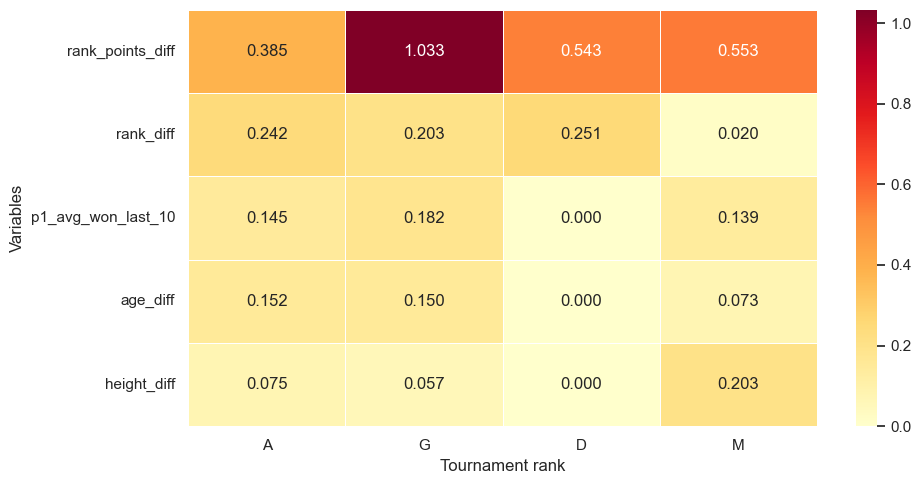

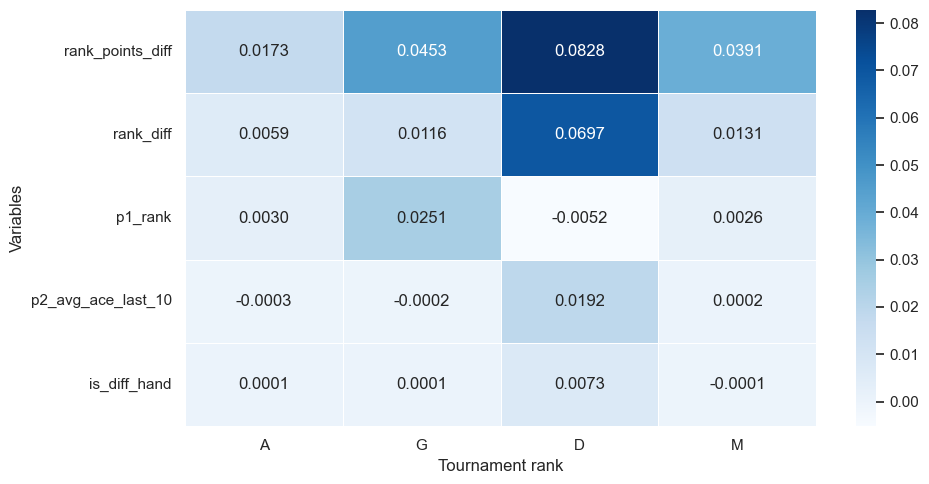

In [44]:
lr_coefs_dict = {}
rf_importance_dict = {}

wszystkie_cechy = [col for col in df_model.columns if col.startswith('surface_')] + features

for level, data in trained_models.items():
    
    best_lr = data['lr']
    best_rf = data['rf']
    X_test = data['X_test']
    y_test = data['y_test']
    
    betas = np.abs(best_lr.named_steps['lr'].coef_[0])
    
    feature_names = best_lr.named_steps['preprocessor'].get_feature_names_out()
    lr_coefs_dict[level] = pd.Series(betas, index=feature_names)
    perm_imp = permutation_importance(best_rf, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=123)
    rf_importance_dict[level] = pd.Series(perm_imp.importances_mean, index=wszystkie_cechy)


df_lr_coefs = pd.DataFrame(lr_coefs_dict).fillna(0)
df_rf_imp = pd.DataFrame(rf_importance_dict).fillna(0)

df_lr_coefs.index = df_lr_coefs.index.str.replace('num__', '').str.replace('remainder__', '')

top5_lr_idx = df_lr_coefs.mean(axis=1).nlargest(5).index
df_lr_top5 = df_lr_coefs.loc[top5_lr_idx]

top5_rf_idx = df_rf_imp.mean(axis=1).nlargest(5).index
df_rf_top5 = df_rf_imp.loc[top5_rf_idx]

sns.set_theme(style="white")

plt.figure(figsize=(10, 5))
sns.heatmap(df_lr_top5, annot=True, cmap="YlOrRd", fmt=".3f", linewidths=.5)
plt.ylabel('Variables', fontsize=12)
plt.xlabel('Tournament rank', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(df_rf_top5, annot=True, cmap="Blues", fmt=".4f", linewidths=.5)
plt.ylabel('Variables', fontsize=12)
plt.xlabel('Tournament rank', fontsize=12)
plt.tight_layout()
plt.show()